In [ ]:
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent))
import numpy as np
import multimin as mm
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from utils.Utils import (
    CanonicalUnits, 
    GravitationalParameters,
    r_fixed_surface_integral_P_X_CMND
    )

In [ ]:
deg = np.pi/180
AU_m = 1.496e11 #m
M_sun = 1.9891e30
G = 6.67430e-11 # m^3 / (kg s^2)
year = 365.25*24*3600 #s
mu = CanonicalUnits().mu
grav_params = GravitationalParameters(mu=mu)

In [ ]:
F = mm.FitCMND(f"../orbital_elements_cmnd/products/fit-NEAS-Ngauss10.pkl")

props=["Q","E","I"]
hargs=dict(bins=20,cmap='YlGn')
sargs=dict(s=0.2,edgecolor='None',color='r', alpha=0.3)
G=F.plotFit(props=props,hargs=hargs,sargs=sargs,figsize=3)

In [ ]:
vx_min, vx_max = -10, 10
vy_min, vy_max = -10, 10

vz_center = 0.0

dvx_cell, dvy_cell, dvz_cell = 0.1, 0.1, 0.1
widths = np.array([dvx_cell, dvy_cell, dvz_cell])

x = 1.0
y = 0.0
z = 0.0
center_r = np.array([x, y, z])

max_elements = (1.30, 1.0, np.pi) 

vx_vals = np.arange(vx_min, vx_max + dvx_cell, dvx_cell)
vy_vals = np.arange(vy_min, vy_max + dvy_cell, dvy_cell)

degree = 6

dtype = [
    ("value", float),
    ("x", float),
    ("y", float)
]

probability_map = np.zeros((len(vy_vals), len(vx_vals)), dtype=dtype)

print("Starting probability mapping...")
for i, vy_c in enumerate(vy_vals):
    for j, vx_c in enumerate(vx_vals):         

        center = np.array([vx_c, vy_c, vz_center])

        try:
        # Calculate the integral for this hypervolume
            prob_value = r_fixed_surface_integral_P_X_CMND(
                center, widths, 
                center_r, 
                max_elements, 
                degree, 
                mu=mu, 
                F=F
            )
        except Exception as err:
            print("Runtime error at center =", center)
            print("   → Setting integral to NaN.")
            #print("   Error message:", err)
            prob_value = np.nan

        # Store the result
        # Note: In plotting, the first index (i) corresponds to rows (y-axis)
        probability_map[i, j] = (prob_value, vx_c, vy_c)
        #print(vx_c, vy_c, prob_value, i, j)
     
# Save to a .dat file
print("Mapping complete!")
np.save(f"results/r_fixed_x_{x}.npy", probability_map)

In [ ]:
## plots config

COLORS = {
    "blue_main":  "#2C7BB6",
    "blue_light": "#92C5DE",
    "blue_dark":  "#08306B",
    "salmon":     "#F46D43",
    "gray_dark":  "#4D4D4D",
    "gray_light": "#BDBDBD",
    "coral": "#FF7F50", 
    "lavender": "#E6E6FA",
    "light_green": "#90EE90",
    "platinum": "#E5E4E2",
    "charcoal": "#36454F",
    "smoke": "#848884",
    "blue_gray": "#7393B3",
    "viridian": "#40826D",
}

mpl.rcParams.update({
    "font.family": "serif",
    "font.size": 11,

    "axes.facecolor": "#FAFBFC",   # very light (Overleaf-safe)
    "figure.facecolor": "white",

    "axes.edgecolor": "black",
    "axes.linewidth": 1.0,

    "xtick.direction": "in",
    "ytick.direction": "in",

    "xtick.major.size": 4,
    "ytick.major.size": 4,
})

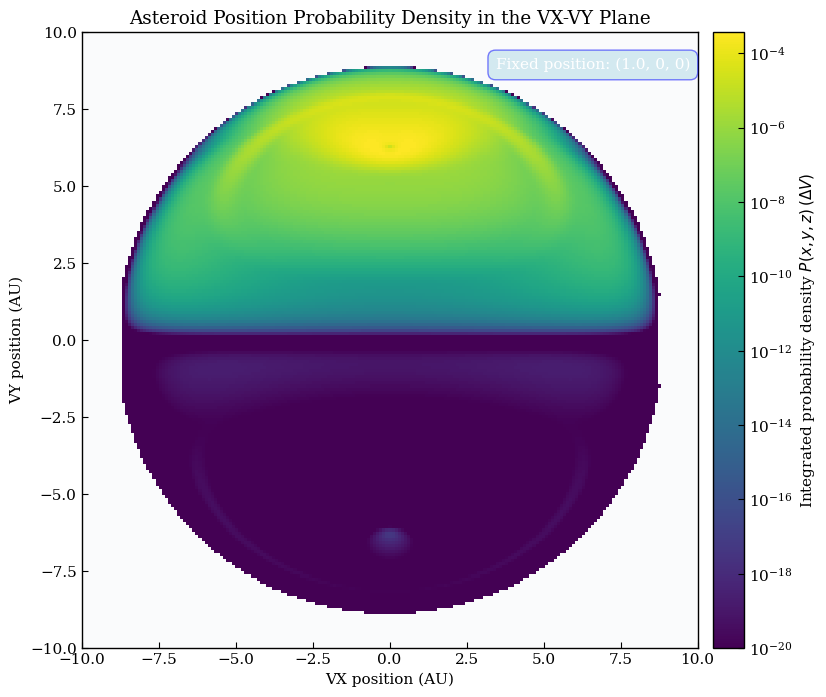

In [14]:
with open("results/r_fixed_x_1.0.npy", "rb") as f:
    integral_grid = np.load(f, allow_pickle=False)

vmin = 1e-20
vmax = np.nanmax(integral_grid['value'])

vx_min, vx_max = -10, 10
vy_min, vy_max = -10, 10
x = 1.0

#plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(
    integral_grid['value'], 
    cmap='viridis',
    extent=[vx_min, vx_max, vy_min, vy_max],
    origin='lower',
    interpolation='nearest',
    norm=LogNorm(vmin=vmin, vmax=vmax)
)

cbar = fig.colorbar(im, ax=ax, pad=0.02)
cbar.set_label(
    r"Integrated probability density $P(x,y,z)\,(\Delta V)$",
    fontsize=11
)

# --- Labels & title ---
ax.set_xlabel("X position [AU]")
ax.set_ylabel("Y position [AU]")
ax.set_title(
    "Asteroid position probability density in the $X$–$Y$ plane",
    pad=10
)

ax.set_aspect("equal", adjustable="box")

ax.set_xlabel('VX position (AU)')
ax.set_ylabel('VY position (AU)')
ax.set_title('Asteroid Position Probability Density in the VX-VY Plane')
ax.set_aspect('equal', adjustable='box') 
ax.text(6.6, 8.8, f'Fixed position: ({x}, 0, 0)', color='white', ha='center', bbox=dict(facecolor='lightblue', alpha=0.5, edgecolor='blue', boxstyle='round,pad=0.5'))
#plt.savefig("figures/PX_fixedv_vxmin=-10_vxmax=10_vymin=-10_vymax=10_x=-1.0.png", dpi=300, bbox_inches='tight')

plt.show()